# BERT

In [32]:
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, classification_report
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer, BertConfig, Trainer, TrainingArguments, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch

In [33]:
MODEL_NAME = 'DeepPavlov/rubert-base-cased'
BATCH_SIZE = 32
MAX_LENGTH = 512
NUM_EPOCHS = 10
RANDOM_SEED = 42

In [34]:
def seed_all(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_all(RANDOM_SEED)

In [35]:
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# text = "Всем привет я Дмитрий! Добро пожаловать на лекцию по NLP"
# encoding = tokenizer(
#     text,
#     truncation=True,
#     padding='max_length',
#     max_length=MAX_LENGTH,
#     return_tensors='pt'
# )
# print(encoding)
# from termcolor import colored

# tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
# attention_mask = encoding['attention_mask'][0]
# input_ids = encoding['input_ids'][0].tolist()

# # Собираем только полезные токены (без PAD)
# real_tokens = [t for t, m in zip(tokens, attention_mask) if m == 1]
# real_ids = [id_ for id_, m in zip(input_ids, attention_mask) if m == 1]

# # Цвета для чередования
# colors = ['red', 'green', 'yellow', 'blue', 'magenta', 'cyan', 'white']

# # Заголовок с номерами токенов
# print("\n№ токена:  ", end='')
# for i in range(len(real_tokens)):
#     print(colored(f'{i:^7}', 'white'), end='')
# print()

# # Разделитель
# print("           " + "─"*7 * len(real_tokens))

# # Строка с токенами
# print("Токены:    ", end='')
# for i, token in enumerate(real_tokens):
#     color = colors[i % len(colors)]
#     display = token.replace('▁', '_')
#     print(colored(f'{display:^7}', color), end='')
# print()

# # Строка с ID токенов
# print("ID:        ", end='')
# for i, token_id in enumerate(real_ids):
#     color = colors[i % len(colors)]
#     print(colored(f'{token_id:^7}', color), end='')
# print()

### Загрузка данных

In [36]:
df = pd.read_csv("../data/ru-hard-detection-clean-v2.csv")

df["label"] = df["source"].map({
    "human": 0,
    "ai": 1
})
df['stratify_col'] = df['label'].astype(str) + "_" + df['dataset'].astype(str)
df['group_id'] = df['dataset'] + "_" + df['id'].astype(str)
df.iloc[478:482]

,id,text,model,source,dataset,noun_ratio,verb_ratio,adj_ratio,avg_word_len,pron_ratio,perf_verb_ratio,punct_ratio,avg_syntax_links,label,stratify_col,group_id
478,479,Творчество Льва Абрамовича Кассиля : нравствен...,deepseek-chat,ai,Corus Essays,0.280702,0.096491,0.142544,6.421875,0.026316,0.318182,0.157895,1.0,1,1_Corus Essays,Corus Essays_479
479,480,"предубеждениями, доказывая, что в борьбе за Ро...",gemini-2.0-flash,ai,Corus Essays,0.325260,0.089965,0.121107,6.122449,0.031142,0.423077,0.152249,1.0,1,1_Corus Essays,Corus Essays_480
480,1,Период с 1922 по 1939 год — время становления ...,NaN,human,Corus Essays,0.355408,0.055188,0.145695,6.391645,0.013245,0.800000,0.154525,1.0,0,0_Corus Essays,Corus Essays_1
481,2,"Время, в которое развернулась деятельность зна...",NaN,human,Corus Essays,0.320713,0.077951,0.129176,6.859375,0.026726,0.657143,0.144766,1.0,0,0_Corus Essays,Corus Essays_2


### Train / test split

In [37]:
def split_data(X, y, group_by):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=group_by))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    return X_train, X_test, y_train, y_test

In [38]:
X = df['text']
y = df['label']

X_train_full, X_test, y_train_full, y_test = split_data(X, y, df["group_id"])
train_groups = df.loc[X_train_full.index, "group_id"]
X_train, X_val, y_train, y_val = split_data(X_train_full, y_train_full, train_groups)

### Создаем датасет

In [39]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):        
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        if isinstance(idx, (list, np.ndarray)):
            idx = idx[0]

        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

### Создаем даталоадеры

In [40]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = TextDataset(
    X_train,
    y_train,
    tokenizer,
    MAX_LENGTH
)

val_dataset = TextDataset(
    X_val,
    y_val,
    tokenizer,
    MAX_LENGTH
)

test_dataset = TextDataset(
    X_test,
    y_test,
    tokenizer,
    MAX_LENGTH
)

In [41]:
train_dataset[200]

{'input_ids': tensor([   101,  58232,    128,  11267, 108893,   3788,  59421,    851,  28176,
          70227,  47721,    132,  13079,  27289,    128,  22927,  10531,  32731,
           3187,  34494,    612,  19506,    861,  82013,    876,    851,  39270,
           1641,  24863,    128,   7788,  62728,  14338,   1758,  20201,    851,
          43917,    132,  11601,   7363,    128,   2752,  37532,   1699,  53345,
           4564,  51946,    128,   3435,  17171,   1758,  36998,    845,  39798,
            851,  41530,  28377,    132,    781,  24317,   7021,  21326,    128,
           1997,  12432,  17872,  42213,   1699,  12926,  13712,    128,    625,
          94583,    128,  26882,  18380,    612,   7214,    128,  29022,    842,
            851,  19235,    842,  43384,   6297,  86447,   2785,  14591,   5206,
            132,  36018,    842, 110374,    626,  42497,  43287,  29167,  15880,
          34494,    845,  26878,  34555,    128,   1997,  12232,  12091,   5257,
           7065

In [42]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [43]:
batch = next(iter(train_loader))
batch

{'input_ids': tensor([[   101,  89663,  16518,  ...,      0,      0,      0],
         [   101,    811,  25291,  ...,      0,      0,      0],
         [   101,  15675,  11894,  ...,      0,      0,      0],
         ...,
         [   101,    110,    110,  ...,      0,      0,      0],
         [   101,  14925,   2739,  ...,      0,      0,      0],
         [   101,  52761, 119390,  ...,      0,      0,      0]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]]),
 'labels': tensor([0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
         0, 1, 1, 0, 0, 1, 1, 1])}

In [44]:
batch["input_ids"].shape

torch.Size([32, 512])

In [45]:
batch["attention_mask"].shape

torch.Size([32, 512])

In [46]:
batch["labels"].shape

torch.Size([32])

In [47]:
len(train_loader)

58

### Настройка параметров обучения

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [49]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those par

#### Настройка оптимизатора

In [50]:
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

total_steps = len(train_loader) * NUM_EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

#### Настройка метрик

In [51]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')
    precision = precision_score(labels, predictions, average='binary')
    recall = recall_score(labels, predictions, average='binary')
    
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [ ]:
version = 3

training_args = TrainingArguments(
    output_dir=f"./models/bert/bert_v{version}",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE, 
    per_device_eval_batch_size=BATCH_SIZE,
    warmup_steps=50,
    weight_decay=0.01,               # регуляризация
    learning_rate = 1e-5,
    logging_steps=10,
    eval_strategy="epoch",
    fp16=True,
    load_best_model_at_end=True,     # загрузить лучшую модель по итогам валидации
    metric_for_best_model="f1",      # ориентируемся на F1-меру    
    seed=RANDOM_SEED,
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    tokenizer = tokenizer,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

### Запуск обучения

In [54]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.276853,0.115209,0.971861,0.972163,0.961864,0.982684
2,0.064713,0.233266,0.937229,0.940937,0.888462,1.000000
3,0.047575,0.079457,0.978355,0.978070,0.991111,0.965368
4,0.013964,0.237576,0.952381,0.954545,0.913043,1.000000
5,0.015682,0.039592,0.991342,0.991342,0.991342,0.991342
6,0.000216,0.200347,0.963203,0.964509,0.931452,1.000000
7,0.000235,0.061376,0.984848,0.985011,0.974576,0.995671
8,0.000119,0.086606,0.982684,0.982906,0.970464,0.995671
9,0.000102,0.094057,0.980519,0.980810,0.966387,0.995671
10,0.000101,0.095058,0.980519,0.980810,0.966387,0.995671


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] Could not locate the best model at ./models/bert/bert_v2\checkpoint-290\pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.


TrainOutput(global_step=580, training_loss=0.06796158733938275, metrics={'train_runtime': 1290.7873, 'train_samples_per_second': 14.255, 'train_steps_per_second': 0.449, 'total_flos': 4841243418624000.0, 'train_loss': 0.06796158733938275, 'epoch': 10.0})

### Сохраняем модель и токенизатор

In [ ]:
trainer.save_model(f"./models/bert/bert_{version}")
tokenizer.save_pretrained(f"./models/bert/bert_v{version}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./models/bert/bert_v2/bert_v2\\tokenizer_config.json',
 './models/bert/bert_v2/bert_v2\\tokenizer.json')

In [67]:
for log in trainer.state.log_history:
    if "eval_f1" in log:
        print(
            f"Epoch: {log['epoch']}, "
            f"F1: {log['eval_f1']:.4f}"
        )

Epoch: 1.0, F1: 0.9722
Epoch: 2.0, F1: 0.9409
Epoch: 3.0, F1: 0.9781
Epoch: 4.0, F1: 0.9545
Epoch: 5.0, F1: 0.9913
Epoch: 6.0, F1: 0.9645
Epoch: 7.0, F1: 0.9850
Epoch: 8.0, F1: 0.9829
Epoch: 9.0, F1: 0.9808
Epoch: 10.0, F1: 0.9808
Epoch: 10.0, F1: 0.9846
Epoch: 10.0, F1: 0.9846
Epoch: 10.0, F1: 0.9846


### Финальный тест

In [66]:
test_results = trainer.evaluate(test_dataset)
print(test_results)
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.000101,0.081573,10,0.984375,0.984615,0.969697,1.000000


{'eval_loss': 0.08157302439212799, 'eval_accuracy': 0.984375, 'eval_f1': 0.9846153846153847, 'eval_precision': 0.9696969696969697, 'eval_recall': 1.0}
eval_loss: 0.0816
eval_accuracy: 0.9844
eval_f1: 0.9846
eval_precision: 0.9697
eval_recall: 1.0000


#### Loss History

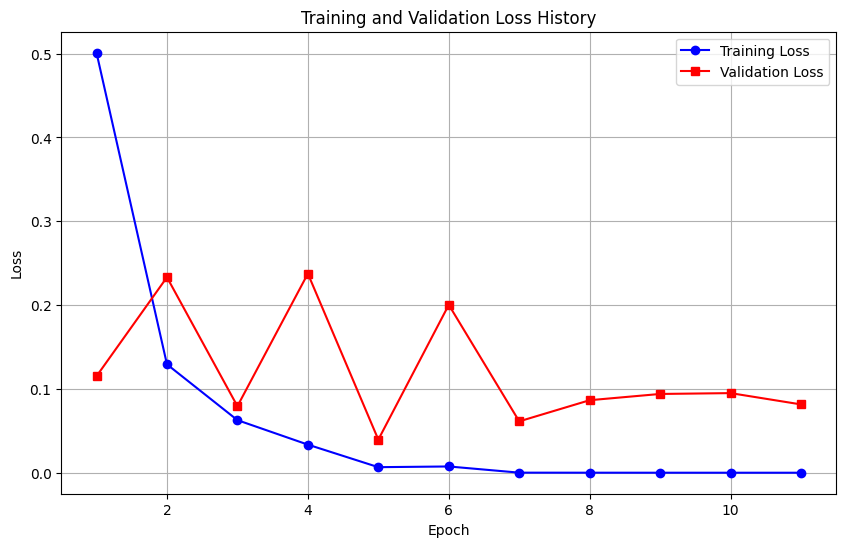

In [57]:
def plot_loss_by_epochs(trainer):
    history = trainer.state.log_history
    
    # 1. Извлекаем чистые данные без лишних записей
    val_l = [x['eval_loss'] for x in history if 'eval_loss' in x]
    train_raw = [(x['epoch'], x['loss']) for x in history if 'loss' in x]
    
    # 2. Группируем и усредняем
    train_l = []
    # Берем только целые числа эпох, которые есть в валидации
    max_epoch = int(len(val_l))
    
    for epoch in range(1, max_epoch + 1):
        # Собираем все логи, которые относятся к текущей эпохе 
        # (от epoch-1 до epoch)
        losses_in_epoch = [l for e, l in train_raw if epoch - 1 < e <= epoch]
        if losses_in_epoch:
            train_l.append(np.mean(losses_in_epoch))
        else:
            # Если данных нет, используем последнее значение или 0, 
            # чтобы не ломать размерность
            train_l.append(train_l[-1] if train_l else 0)

    # 3. Отрисовка
    plt.figure(figsize=(10, 6))
    
    # Теперь оси гарантированно одинаковой длины
    epochs_range = range(1, len(val_l) + 1)
    
    plt.plot(epochs_range, train_l, label='Training Loss', marker='o', color='blue')
    plt.plot(epochs_range, val_l, label='Validation Loss', marker='s', color='red')
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss History')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_by_epochs(trainer)

In [58]:
test_output = trainer.predict(test_dataset)
y_true = test_output.label_ids
y_pred = np.argmax(test_output.predictions, axis=-1)

report = classification_report(y_true, y_pred, target_names=['0.0', '1.0'], digits=4)

print("=" * 50)
print("CLASSIFICATION REPORT (threshold=0.5)")
print("=" * 50)
print(report)

CLASSIFICATION REPORT (threshold=0.5)
              precision    recall  f1-score   support

         0.0     1.0000    0.9688    0.9841       288
         1.0     0.9697    1.0000    0.9846       288

    accuracy                         0.9844       576
   macro avg     0.9848    0.9844    0.9844       576
weighted avg     0.9848    0.9844    0.9844       576



#### Матрица ошибок

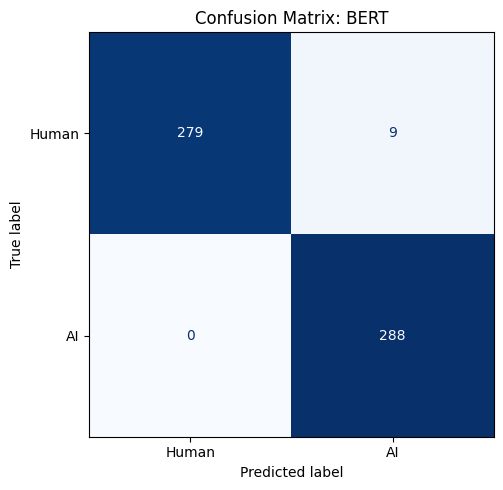

In [59]:
y_true = test_output.label_ids
y_pred = np.argmax(test_output.predictions, axis=-1)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'AI'])

disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix: BERT")

plt.tight_layout()
plt.show()

#### ROC-кривая

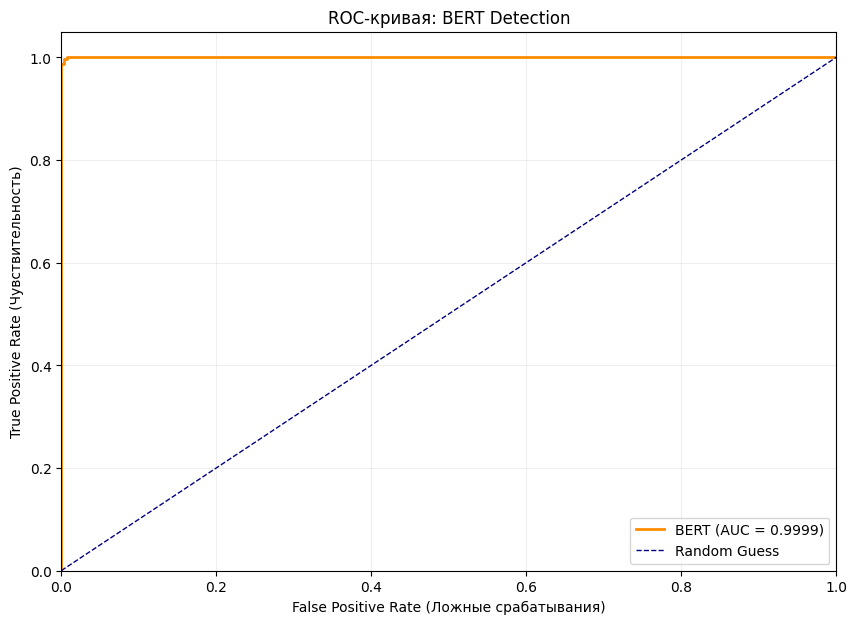

In [60]:
logits = torch.from_numpy(test_output.predictions)
y_score = F.softmax(logits, dim=-1)[:, 1].numpy()

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'BERT (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('ROC-кривая: BERT Detection')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()